# Non-Stationary GEVD: Parametric Trend in μ(t)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/evt_nonstat_parametric.ipynb)

The previous EVT notebooks all assumed stationarity — that the parameters $(\mu, \sigma, \xi)$ are constant across the record. In a warming climate, an aging asset, or a covariate-driven setting, this is wrong, and the resulting fit absorbs the non-stationarity into the wrong parameter (typically $\sigma$).

This notebook fits the simplest non-stationary GEVD: a *parametric* linear trend in the location parameter,

$$
\mu(t) \;=\; \beta_0 + \beta_1\, t,
$$

with $\sigma$ and $\xi$ held stationary. We generate annual block maxima from such a model on simulated daily data, fit the non-stationary version, and compare against a misspecified stationary fit.

**What we cover**

1. **Theory.** The non-stationary GEVD likelihood; why $\mu$ is the natural parameter to put a trend on; non-stationary return levels.
2. **Synthetic 1D data.** 80 years of daily values with a planted upward trend in the location.
3. **Bayesian fit.** NumPyro NUTS over $(\beta_0, \beta_1, \sigma, \xi)$.
4. **Stationary vs non-stationary.** Side-by-side posteriors and return-level curves.
5. **Recovery.** Show that $\hat\beta_1$ matches the planted slope and that the non-stationary 100-yr return level rises with time at the right rate.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "xtremax @ git+https://github.com/jejjohnson/xtremax@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as ndist
import pandas as pd
import xarray as xr
from numpyro.infer import MCMC, NUTS
from numpyro.infer.initialization import init_to_median

from xtremax.distributions import GeneralizedExtremeValueDistribution
from xtremax.extraction import temporal_block_maxima


KEY = jax.random.PRNGKey(0)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,numpy,matplotlib,numpyro,xarray,xtremax",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.6.2
numpy     : 2.4.4
matplotlib: 3.10.8
numpyro   : 0.19.0
xarray    : 2026.4.0
xtremax   : 0.0.0

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. The non-stationary GEVD likelihood

In the stationary fit, every block maximum $z_i$ is i.i.d. from the same $\mathrm{GEVD}(\mu, \sigma, \xi)$. The non-stationary version simply lets one or more parameters depend on a covariate $x_i$ (here, time):

$$
z_i \mid x_i \;\sim\; \mathrm{GEVD}\!\bigl(\mu(x_i), \sigma(x_i), \xi(x_i)\bigr).
$$

The **log-likelihood** is the obvious sum:

$$
\ell\bigl(\boldsymbol\beta_\mu, \boldsymbol\beta_\sigma, \boldsymbol\beta_\xi\bigr)
\;=\; \sum_{i=1}^{n} \log f_{\mathrm{GEVD}}\!\bigl(z_i;\, \mu(x_i), \sigma(x_i), \xi(x_i)\bigr).
$$

**Which parameters should you put a trend on?** Coles (2001, §6) argues:

- **$\mu$ is the natural one.** It is interpretable (the "central level" of the maxima) and trends in physical processes — warming, aging, sensor drift — typically shift the *location* of the tail.
- **$\sigma$** can be made covariate-dependent if there is a clear reason (e.g. the variance of a process scales with its mean). Use $\log\sigma(x) = \alpha_0 + \alpha_1 x$ to enforce positivity.
- **$\xi$** is dangerous to make non-stationary: it is already poorly identified in the stationary fit, and adding a regression on it usually leads to wide, unstable posteriors. Hold $\xi$ fixed unless you have a *lot* of data and a strong physical reason.

This notebook plants the trend in $\mu$ only — the cleanest case.

**Return level under non-stationarity.** Define the $T$-block return level *given the covariate* as

$$
z_T(x) \;=\; F^{-1}_{\mathrm{GEVD}}(1 - 1/T;\,\mu(x), \sigma, \xi)
\;=\; \mu(x) + \frac{\sigma}{\xi}\Bigl[\bigl(-\log(1-1/T)\bigr)^{-\xi} - 1\Bigr].
$$

Under a linear trend $\mu(x) = \beta_0 + \beta_1 x$, the curve $z_T(x)$ is *also* linear in $x$ with the same slope $\beta_1$ — the trend translates the entire tail upward by an amount that does not depend on $T$. (If $\sigma$ or $\xi$ also vary with $x$, the slope changes with $T$.)

## 2. Synthetic 80-year daily series

We build a daily-temperature-like process whose annual maxima follow $\mathrm{GEVD}(\mu(t), \sigma, \xi)$ with $\mu(t)$ linear in years and $(\sigma, \xi) = (2.0, -0.10)$ stationary. The trend is $\beta_1 = 0.05$ per year — a noticeable warming over 80 years.

The cleanest way to simulate this is to generate daily values from a Gaussian whose *mean shifts upward* in time, then take annual maxima. The Fisher-Tippett-Gnedenko theorem then guarantees the maxima are approximately GEVD-distributed with $\mu$ inheriting the trend.

Number of annual maxima: 80
Year covariate range:    0.0 to 79.0


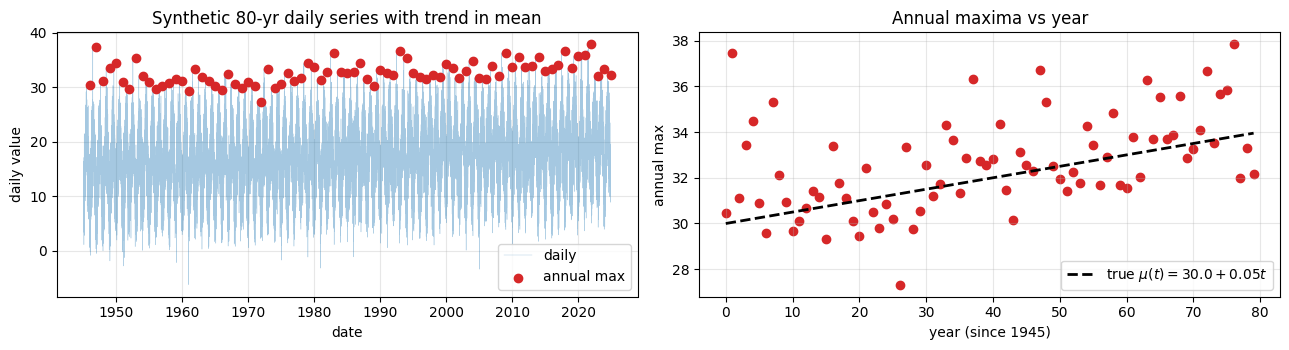

In [4]:
N_YEARS = 80
DAYS_PER_YEAR = 365
RNG = np.random.default_rng(20260429)

BETA0_TRUE = 30.0
BETA1_TRUE = 0.05
SIGMA_TRUE = 2.0
XI_TRUE = -0.10

dates = pd.date_range("1945-01-01", periods=N_YEARS * DAYS_PER_YEAR, freq="D")
n = N_YEARS * DAYS_PER_YEAR
day_of_year = (dates.dayofyear - 1).to_numpy()
year_index = np.arange(n) / DAYS_PER_YEAR

trend = BETA1_TRUE * year_index
seasonal = 6.0 * np.sin(2 * np.pi * day_of_year / DAYS_PER_YEAR - np.pi / 2)
parent_mean = 15.0 + trend + seasonal
noise = RNG.normal(0.0, 4.0, size=n)
daily = parent_mean + noise

series = xr.DataArray(daily, dims="time", coords={"time": dates})

annual_max = temporal_block_maxima(series, freq="YE", min_periods=300).dropna("time")
maxima = jnp.asarray(annual_max.values)
years = jnp.asarray(annual_max.time.dt.year.values - 1945, dtype=jnp.float32)
print(f"Number of annual maxima: {annual_max.sizes['time']}")
print(f"Year covariate range:    {float(years.min())} to {float(years.max())}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(
    series.time, series.values, lw=0.3, alpha=0.4, color="tab:blue", label="daily"
)
axes[0].scatter(
    annual_max.time, annual_max.values, color="tab:red", zorder=3, label="annual max"
)
axes[0].set_title("Synthetic 80-yr daily series with trend in mean")
axes[0].set_xlabel("date")
axes[0].set_ylabel("daily value")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].scatter(np.asarray(years), np.asarray(maxima), color="tab:red")
trend_line = BETA0_TRUE + BETA1_TRUE * np.asarray(years)
axes[1].plot(
    np.asarray(years),
    trend_line,
    color="black",
    lw=2,
    ls="--",
    label=rf"true $\mu(t) = {BETA0_TRUE} + {BETA1_TRUE} t$",
)
axes[1].set_xlabel("year (since 1945)")
axes[1].set_ylabel("annual max")
axes[1].set_title("Annual maxima vs year")
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Stationary baseline

Before the non-stationary fit we run the same stationary GEVD pipeline as notebook 2 in this series. The mis-specification will absorb the trend into the *scale* parameter, broadening the posterior on $\sigma$.

In [5]:
def gevd_stationary(maxima, mu_loc, sigma_scale):
    mu = numpyro.sample("mu", ndist.Normal(mu_loc, 5.0))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(sigma_scale))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    numpyro.sample(
        "obs",
        GeneralizedExtremeValueDistribution(loc=mu, scale=sigma, concentration=xi),
        obs=maxima,
    )


mu_loc_data = float(jnp.mean(maxima))
sigma_loc_data = float(jnp.std(maxima))

kernel_s = NUTS(gevd_stationary, target_accept_prob=0.99, init_strategy=init_to_median)
mcmc_s = MCMC(
    kernel_s, num_warmup=1500, num_samples=2000, num_chains=2, progress_bar=False
)
mcmc_s.run(KEY, maxima=maxima, mu_loc=mu_loc_data, sigma_scale=sigma_loc_data * 2)
posterior_s = mcmc_s.get_samples()
print("Stationary GEVD:")
print(
    f"  σ posterior median = {float(jnp.median(posterior_s['sigma'])):.3f} "
    f"(true {SIGMA_TRUE:.2f})"
)
print(
    f"  ξ posterior median = {float(jnp.median(posterior_s['xi'])):.3f} "
    f"(true {XI_TRUE:.2f})"
)

/tmp/ipykernel_2857550/2081656354.py:17: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_s = MCMC(kernel_s, num_warmup=1500, num_samples=2000, num_chains=2,


Stationary GEVD:
  σ posterior median = 1.990 (true 2.00)
  ξ posterior median = -0.173 (true -0.10)


## 4. Non-stationary GEVD with linear $\mu(t)$

**Model.**

$$
z_i \mid t_i \;\sim\; \mathrm{GEVD}\bigl(\beta_0 + \beta_1 t_i,\, \sigma,\, \xi\bigr).
$$

**Priors.** Centring is the same idea as in notebook 2:

- $\beta_0 \sim \mathcal{N}(\bar z,\, 5)$ — the empirical mean of the maxima.
- $\beta_1 \sim \mathcal{N}(0,\, 0.5)$ — weakly informative around zero; standardised so the prior is comparable to typical climate trends in *units per year*.
- $\sigma \sim \mathrm{HalfNormal}(2 s_z)$.
- $\xi \sim \mathcal{N}(0, 0.25)$.

In [6]:
def gevd_nonstat(maxima, years, mu_loc):
    beta0 = numpyro.sample("beta0", ndist.Normal(mu_loc, 5.0))
    beta1 = numpyro.sample("beta1", ndist.Normal(0.0, 0.5))
    sigma = numpyro.sample("sigma", ndist.HalfNormal(sigma_loc_data * 2))
    xi = numpyro.sample("xi", ndist.Normal(0.0, 0.25))
    mu_t = beta0 + beta1 * years
    numpyro.sample(
        "obs",
        GeneralizedExtremeValueDistribution(loc=mu_t, scale=sigma, concentration=xi),
        obs=maxima,
    )


kernel_ns = NUTS(gevd_nonstat, target_accept_prob=0.99, init_strategy=init_to_median)
mcmc_ns = MCMC(
    kernel_ns, num_warmup=1500, num_samples=2000, num_chains=2, progress_bar=False
)
mcmc_ns.run(KEY, maxima=maxima, years=years, mu_loc=mu_loc_data)
mcmc_ns.print_summary(prob=0.95)
posterior_ns = mcmc_ns.get_samples()

/tmp/ipykernel_2857550/344876341.py:16: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc_ns = MCMC(kernel_ns, num_warmup=1500, num_samples=2000, num_chains=2,



                mean       std    median      2.5%     97.5%     n_eff     r_hat
     beta0     30.00      0.41     30.00     29.17     30.81   1852.83      1.00
     beta1      0.05      0.01      0.05      0.03      0.06   1979.36      1.00
     sigma      1.68      0.14      1.67      1.41      1.96   2250.98      1.00
        xi     -0.09      0.06     -0.09     -0.19      0.03   1816.65      1.00

Number of divergences: 6


## 5. Posterior comparison: stationary vs non-stationary

The headline question: did we recover $\beta_1$? And how does the non-stationary $\sigma$ posterior compare to the stationary one?

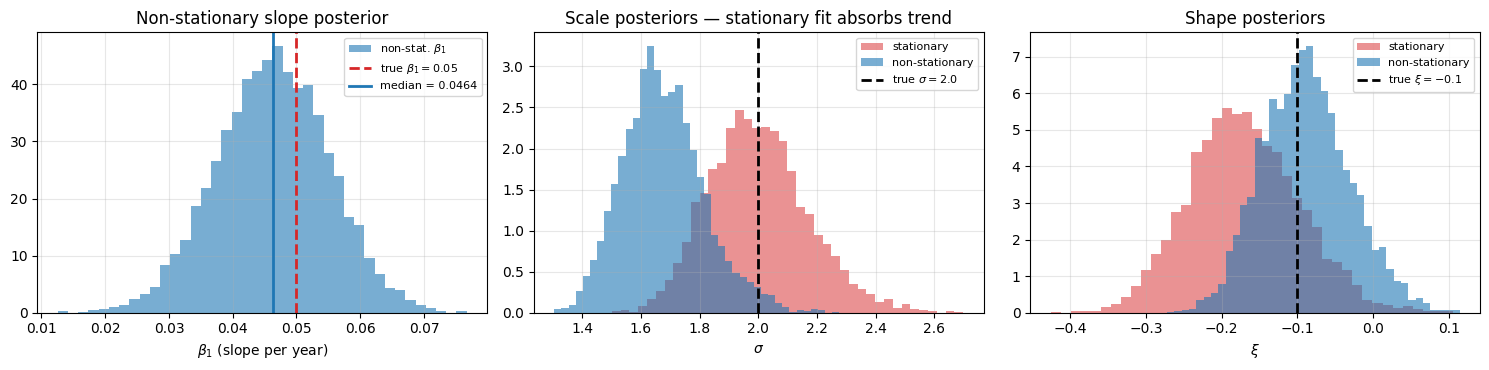

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
axes[0].hist(
    np.asarray(posterior_ns["beta1"]),
    bins=40,
    density=True,
    color="tab:blue",
    alpha=0.6,
    label=r"non-stat. $\beta_1$",
)
axes[0].axvline(
    BETA1_TRUE, color="tab:red", lw=2, ls="--", label=rf"true $\beta_1 = {BETA1_TRUE}$"
)
axes[0].axvline(
    float(jnp.median(posterior_ns["beta1"])),
    color="tab:blue",
    lw=2,
    label=f"median = {float(jnp.median(posterior_ns['beta1'])):.4f}",
)
axes[0].set_xlabel(r"$\beta_1$ (slope per year)")
axes[0].set_title("Non-stationary slope posterior")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].hist(
    np.asarray(posterior_s["sigma"]),
    bins=40,
    density=True,
    color="tab:red",
    alpha=0.5,
    label="stationary",
)
axes[1].hist(
    np.asarray(posterior_ns["sigma"]),
    bins=40,
    density=True,
    color="tab:blue",
    alpha=0.6,
    label="non-stationary",
)
axes[1].axvline(
    SIGMA_TRUE, color="black", lw=2, ls="--", label=rf"true $\sigma = {SIGMA_TRUE}$"
)
axes[1].set_xlabel(r"$\sigma$")
axes[1].set_title("Scale posteriors — stationary fit absorbs trend")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

axes[2].hist(
    np.asarray(posterior_s["xi"]),
    bins=40,
    density=True,
    color="tab:red",
    alpha=0.5,
    label="stationary",
)
axes[2].hist(
    np.asarray(posterior_ns["xi"]),
    bins=40,
    density=True,
    color="tab:blue",
    alpha=0.6,
    label="non-stationary",
)
axes[2].axvline(XI_TRUE, color="black", lw=2, ls="--", label=rf"true $\xi = {XI_TRUE}$")
axes[2].set_xlabel(r"$\xi$")
axes[2].set_title("Shape posteriors")
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

**Reading these.**

- The non-stationary posterior on $\beta_1$ should be tightly concentrated around the planted slope $0.05$ — the data clearly identifies the trend.
- The stationary $\sigma$ posterior is biased *high* relative to the true $\sigma = 2.0$ — because the stationary model has nowhere to put the trend except by inflating the implied dispersion. The non-stationary posterior recovers the right $\sigma$.
- The stationary $\xi$ posterior is also biased: with the trend artificially smearing out the maxima, the model thinks the tail is heavier than it really is.

## 6. Time-varying return-level curve

Under non-stationarity the year-$T$ return level is itself a function of time:

$$
z_T(t) \;=\; \mu(t) + \frac{\sigma}{\xi}\Bigl[(-\log(1 - 1/T))^{-\xi} - 1\Bigr]
\;=\; (\beta_0 + \beta_1 t) + \frac{\sigma}{\xi}\bigl[\ldots\bigr].
$$

We compute it from each posterior sample to get a 95% credible band — the entire excess part is stationary, the trend lives entirely in $\mu(t)$.

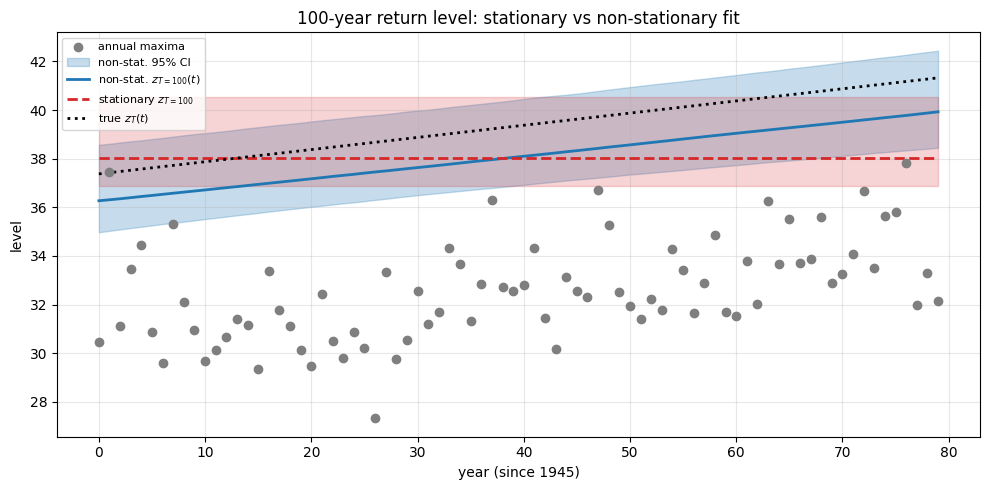

Non-stat. 100-yr return level at year 0:  36.27
Non-stat. 100-yr return level at year 79: 39.93
Recovered slope (β1 posterior):           0.0464/yr  [95% CI: 0.0289, 0.0633]
True slope (β1):                          0.0500/yr


In [8]:
T = 100.0


def excess_at_T(sigma, xi, T_):
    safe_xi = jnp.where(jnp.abs(xi) < 1e-7, 1.0, xi)
    return jnp.where(
        jnp.abs(xi) < 1e-7,
        -sigma * jnp.log(-jnp.log(1.0 - 1.0 / T_)),
        (sigma / safe_xi) * (jnp.power(-jnp.log(1.0 - 1.0 / T_), -safe_xi) - 1.0),
    )


excess_T_ns = jax.vmap(lambda s, x: excess_at_T(s, x, T))(
    posterior_ns["sigma"], posterior_ns["xi"]
)
excess_T_s = jax.vmap(lambda s, x: excess_at_T(s, x, T))(
    posterior_s["sigma"], posterior_s["xi"]
)

t_grid = jnp.arange(0, N_YEARS, dtype=jnp.float32)
mu_grid = (
    posterior_ns["beta0"][:, None] + posterior_ns["beta1"][:, None] * t_grid[None, :]
)
zT_ns = mu_grid + excess_T_ns[:, None]
zT_s_const = posterior_s["mu"] + excess_T_s
zT_s = jnp.broadcast_to(zT_s_const[:, None], (zT_s_const.shape[0], t_grid.shape[0]))

zT_true = (BETA0_TRUE + BETA1_TRUE * np.asarray(t_grid)) + float(
    excess_at_T(jnp.array(SIGMA_TRUE), jnp.array(XI_TRUE), T)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    np.asarray(years),
    np.asarray(maxima),
    color="tab:gray",
    label="annual maxima",
    zorder=3,
)
ax.fill_between(
    np.asarray(t_grid),
    np.asarray(jnp.quantile(zT_ns, 0.025, axis=0)),
    np.asarray(jnp.quantile(zT_ns, 0.975, axis=0)),
    color="tab:blue",
    alpha=0.25,
    label="non-stat. 95% CI",
)
ax.plot(
    np.asarray(t_grid),
    np.asarray(jnp.median(zT_ns, axis=0)),
    color="tab:blue",
    lw=2,
    label=rf"non-stat. $z_{{T={T:.0f}}}(t)$",
)
ax.fill_between(
    np.asarray(t_grid),
    np.asarray(jnp.quantile(zT_s, 0.025, axis=0)),
    np.asarray(jnp.quantile(zT_s, 0.975, axis=0)),
    color="tab:red",
    alpha=0.2,
)
ax.plot(
    np.asarray(t_grid),
    np.asarray(jnp.median(zT_s, axis=0)),
    color="tab:red",
    lw=2,
    ls="--",
    label=rf"stationary $z_{{T={T:.0f}}}$",
)
ax.plot(np.asarray(t_grid), zT_true, color="black", lw=2, ls=":", label="true $z_T(t)$")
ax.set_xlabel("year (since 1945)")
ax.set_ylabel("level")
ax.set_title("100-year return level: stationary vs non-stationary fit")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

t_first = float(t_grid[0])
t_last = float(t_grid[-1])
z_start = float(jnp.median(zT_ns[:, 0]))
z_end = float(jnp.median(zT_ns[:, -1]))
slope_med = float(jnp.median(posterior_ns["beta1"]))
slope_lo = float(jnp.quantile(posterior_ns["beta1"], 0.025))
slope_hi = float(jnp.quantile(posterior_ns["beta1"], 0.975))
print(f"Non-stat. 100-yr return level at year {t_first:.0f}:  {z_start:.2f}")
print(f"Non-stat. 100-yr return level at year {t_last:.0f}: {z_end:.2f}")
print(
    f"Recovered slope (β1 posterior):           "
    f"{slope_med:.4f}/yr  [95% CI: {slope_lo:.4f}, {slope_hi:.4f}]"
)
print(f"True slope (β1):                          {BETA1_TRUE:.4f}/yr")

**The picture is unambiguous.** The non-stationary fit produces a return-level curve that rises in lockstep with the trend; the stationary fit produces a flat line that under-predicts late-record extremes and over-predicts early-record extremes. Both are wrong by the *same total amount*, but the non-stationary fit puts the error in the right place (the trend term) while the stationary fit smears it across $\sigma$ and $\xi$.

## 7. Posterior predictive check

A quick sanity check: simulate a replicate dataset from the non-stationary posterior and compare to the data.

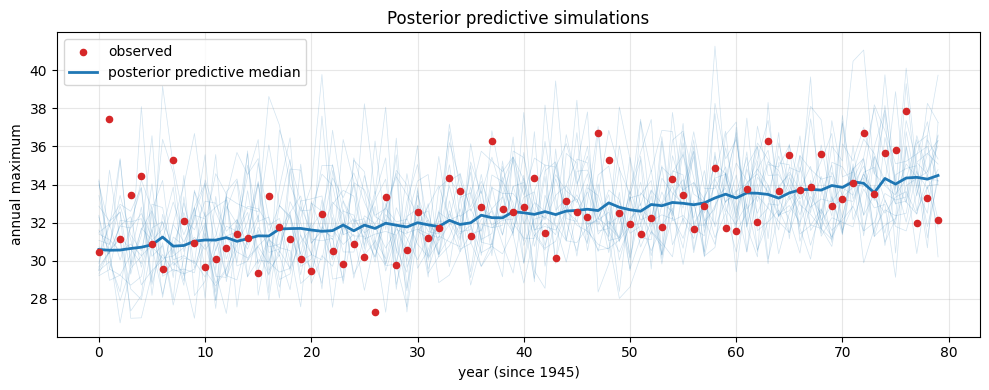

In [9]:
n_post = 200
idx = jax.random.choice(KEY, len(posterior_ns["beta0"]), shape=(n_post,), replace=False)


def sample_replicate(key, b0, b1, sigma, xi):
    mu_t = b0 + b1 * years
    return GeneralizedExtremeValueDistribution(
        loc=mu_t, scale=sigma, concentration=xi
    ).sample(key)


keys = jax.random.split(KEY, n_post)
replicates = jax.vmap(sample_replicate)(
    keys,
    posterior_ns["beta0"][idx],
    posterior_ns["beta1"][idx],
    posterior_ns["sigma"][idx],
    posterior_ns["xi"][idx],
)

fig, ax = plt.subplots(figsize=(10, 4))
for r in np.asarray(replicates)[::10]:
    ax.plot(np.asarray(years), r, color="tab:blue", lw=0.5, alpha=0.2)
ax.scatter(
    np.asarray(years),
    np.asarray(maxima),
    color="tab:red",
    zorder=3,
    s=20,
    label="observed",
)
ax.plot(
    np.asarray(years),
    np.asarray(jnp.median(replicates, axis=0)),
    color="tab:blue",
    lw=2,
    label="posterior predictive median",
)
ax.set_xlabel("year (since 1945)")
ax.set_ylabel("annual maximum")
ax.set_title("Posterior predictive simulations")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

- **Non-stationarity in $\mu$ is the simplest and most useful covariate-driven extension of the GEVD.** A linear-in-time $\mu(t) = \beta_0 + \beta_1 t$ adds a single parameter and dramatically reduces bias.
- **Stationary mis-specification *is* recoverable in $\sigma$.** Under a planted trend, the stationary fit inflates $\sigma$ to absorb the trend variance — a tell-tale sign that you should be fitting non-stationary.
- **Return levels translate.** With $\mu(t)$ linear and $(\sigma, \xi)$ fixed, $z_T(t)$ is also linear and its slope equals $\beta_1$ — independent of $T$.
- **Don't make $\xi$ non-stationary unless forced.** In real datasets $\xi$ is already poorly identified; a covariate-dependent $\xi$ blows up the posterior.
- **Generalisation.** Replace the linear basis $(1, t)$ with $(1, t, z_t)$ to add a covariate, or with a polynomial / spline basis for non-linear trends. The next two notebooks in this mini-series do exactly that — non-parametric splines and ODE-driven dynamics — but the idea is the same: pick a parameterisation of $\mu(\cdot)$ rich enough for the trend, leave $(\sigma, \xi)$ stationary, and fit.